In [21]:
from google.colab import files

print("Upload actuals-jan2024-clean.json")
uploaded = files.upload()

print("Now upload forecasts-jan2024.json")
uploaded2 = files.upload()

Upload actuals-jan2024-clean.json


Saving actuals-jan2024-clean.json to actuals-jan2024-clean (2).json
Now upload forecasts-jan2024.json


Saving forecasts-jan2024.json to forecasts-jan2024 (2).json


In [22]:
import json
import pandas as pd

with open("actuals-jan2024-clean.json") as f:
    actuals_raw = json.load(f)

with open("forecasts-jan2024.json") as f:
    forecasts_raw = json.load(f)

actuals = pd.DataFrame(actuals_raw)
forecasts = pd.DataFrame(forecasts_raw)

actuals["startTime"] = pd.to_datetime(actuals["startTime"])
forecasts["startTime"] = pd.to_datetime(forecasts["startTime"])
forecasts["publishTime"] = pd.to_datetime(forecasts["publishTime"])

print("Actuals shape:", actuals.shape)
print("Forecasts shape:", forecasts.shape)
print()
print("Actuals sample:")
print(actuals.head(3))
print()
print("Forecasts sample:")
print(forecasts.head(3))

Actuals shape: (1472, 2)
Forecasts shape: (1426, 5)

Actuals sample:
                  startTime  generation
0 2024-01-01 00:00:00+00:00       11713
1 2024-01-01 00:30:00+00:00       12232
2 2024-01-01 01:00:00+00:00       12702

Forecasts sample:
                publishTime                 startTime settlementDate  \
0 2023-12-31 22:30:00+00:00 2024-01-01 00:00:00+00:00     2024-01-01   
1 2023-12-30 02:30:00+00:00 2024-01-01 00:00:00+00:00     2024-01-01   
2 2023-12-31 22:30:00+00:00 2024-01-01 01:00:00+00:00     2024-01-01   

   settlementPeriod  generation  
0                 1       11453  
1                 1       11145  
2                 3       11838  


In [23]:
forecasts["horizon_hours"] = (
    forecasts["startTime"] - forecasts["publishTime"]
).dt.total_seconds() / 3600

print("Horizon range before filter:")
print(f"  Min: {forecasts['horizon_hours'].min():.1f}h")
print(f"  Max: {forecasts['horizon_hours'].max():.1f}h")
print(f"  Total records: {len(forecasts)}")

forecasts_filtered = forecasts[
    (forecasts["horizon_hours"] >= 0) &
    (forecasts["horizon_hours"] <= 48)
].copy()

print()
print("After filtering to 0–48h horizon:")
print(f"  Min: {forecasts_filtered['horizon_hours'].min():.1f}h")
print(f"  Max: {forecasts_filtered['horizon_hours'].max():.1f}h")
print(f"  Total records: {len(forecasts_filtered)}")

Horizon range before filter:
  Min: 0.5h
  Max: 66.5h
  Total records: 1426

After filtering to 0–48h horizon:
  Min: 0.5h
  Max: 47.5h
  Total records: 837


In [24]:
merged = pd.merge(
    forecasts_filtered,
    actuals,
    on="startTime",
    suffixes=("_forecast", "_actual")
)

merged["error"] = merged["generation_forecast"] - merged["generation_actual"]
merged["abs_error"] = merged["error"].abs()

print("Merged records:", len(merged))
print()
print("Sample of merged data:")
print(merged[["startTime", "publishTime", "horizon_hours",
              "generation_forecast", "generation_actual",
              "error", "abs_error"]].head(5).to_string())

Merged records: 828

Sample of merged data:
                  startTime               publishTime  horizon_hours  generation_forecast  generation_actual  error  abs_error
0 2024-01-01 00:00:00+00:00 2023-12-31 22:30:00+00:00            1.5                11453              11713   -260        260
1 2024-01-01 00:00:00+00:00 2023-12-30 02:30:00+00:00           45.5                11145              11713   -568        568
2 2024-01-01 01:00:00+00:00 2023-12-31 22:30:00+00:00            2.5                11838              12702   -864        864
3 2024-01-01 01:00:00+00:00 2023-12-30 02:30:00+00:00           46.5                11383              12702  -1319       1319
4 2024-01-01 02:00:00+00:00 2023-12-31 22:30:00+00:00            3.5                12090              12849   -759        759


In [25]:
import numpy as np

mae = merged["abs_error"].mean()
median_ae = merged["abs_error"].median()
p99_ae = merged["abs_error"].quantile(0.99)
rmse = np.sqrt((merged["error"] ** 2).mean())
mean_bias = merged["error"].mean()

print("=" * 45)
print("   FORECAST ERROR STATISTICS (Jan 2024)")
print("=" * 45)
print(f"  Total paired observations : {len(merged)}")
print(f"  Mean Absolute Error (MAE) : {mae:.0f} MW")
print(f"  Median Absolute Error     : {median_ae:.0f} MW")
print(f"  P99 Absolute Error        : {p99_ae:.0f} MW")
print(f"  RMSE                      : {rmse:.0f} MW")
print(f"  Mean Bias (signed)        : {mean_bias:.0f} MW")
print("=" * 45)
print()
if mean_bias < 0:
    print(f"  ⚠ Model tends to UNDER-forecast by {abs(mean_bias):.0f} MW on average")
else:
    print(f"  ⚠ Model tends to OVER-forecast by {mean_bias:.0f} MW on average")

   FORECAST ERROR STATISTICS (Jan 2024)
  Total paired observations : 828
  Mean Absolute Error (MAE) : 1985 MW
  Median Absolute Error     : 1122 MW
  P99 Absolute Error        : 13471 MW
  RMSE                      : 3356 MW
  Mean Bias (signed)        : -324 MW

  ⚠ Model tends to UNDER-forecast by 324 MW on average


horizon_bucket        mean  median      p99  count
          0–6h 1749.459016  1034.0 14237.08    183
         6–12h 1845.682796  1218.5 12193.95    186
        12–24h 2025.850649  1025.0 13372.86    308
        36–48h 2359.251656  1219.0 12776.50    151



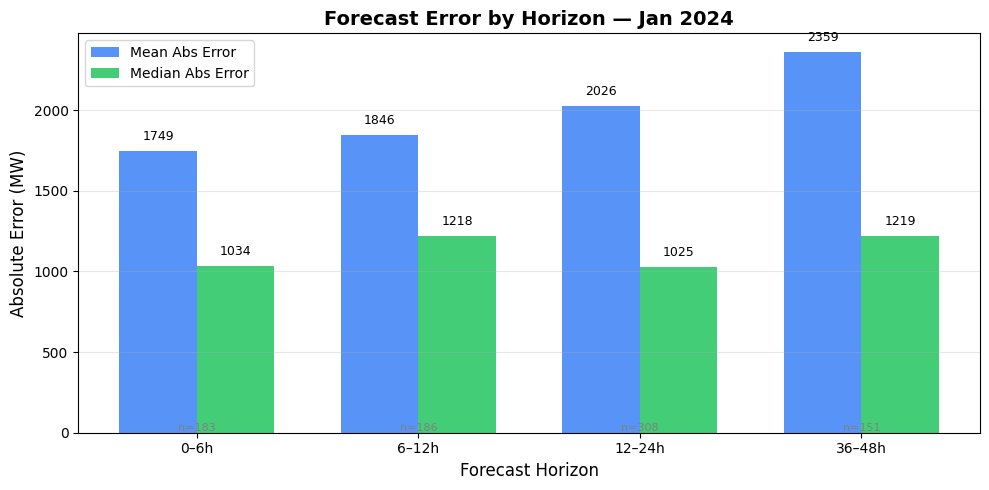

Chart saved.


In [26]:
import matplotlib.pyplot as plt

bins = [0, 6, 12, 24, 36, 48]
labels = ["0–6h", "6–12h", "12–24h", "24–36h", "36–48h"]

merged["horizon_bucket"] = pd.cut(
    merged["horizon_hours"],
    bins=bins,
    labels=labels
)

horizon_stats = merged.groupby("horizon_bucket", observed=True)["abs_error"].agg(
    mean="mean",
    median="median",
    p99=lambda x: x.quantile(0.99),
    count="count"
).reset_index()

print(horizon_stats.to_string(index=False))
print()

actual_labels = horizon_stats["horizon_bucket"].tolist()
x = range(len(actual_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))

bars1 = ax.bar([i - width/2 for i in x], horizon_stats["mean"],
                width, label="Mean Abs Error", color="#3b82f6", alpha=0.85)
bars2 = ax.bar([i + width/2 for i in x], horizon_stats["median"],
                width, label="Median Abs Error", color="#22c55e", alpha=0.85)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f"{bar.get_height():.0f}", ha="center", va="bottom", fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f"{bar.get_height():.0f}", ha="center", va="bottom", fontsize=9)

ax.set_xlabel("Forecast Horizon", fontsize=12)
ax.set_ylabel("Absolute Error (MW)", fontsize=12)
ax.set_title("Forecast Error by Horizon — Jan 2024", fontsize=14, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(actual_labels)
ax.legend()
ax.grid(axis="y", alpha=0.3)

for i, row in horizon_stats.iterrows():
    ax.text(i, 10, f"n={row['count']}", ha="center",
            fontsize=8, color="gray")

plt.tight_layout()
plt.savefig("error_by_horizon.png", dpi=150)
plt.show()
print("Chart saved.")

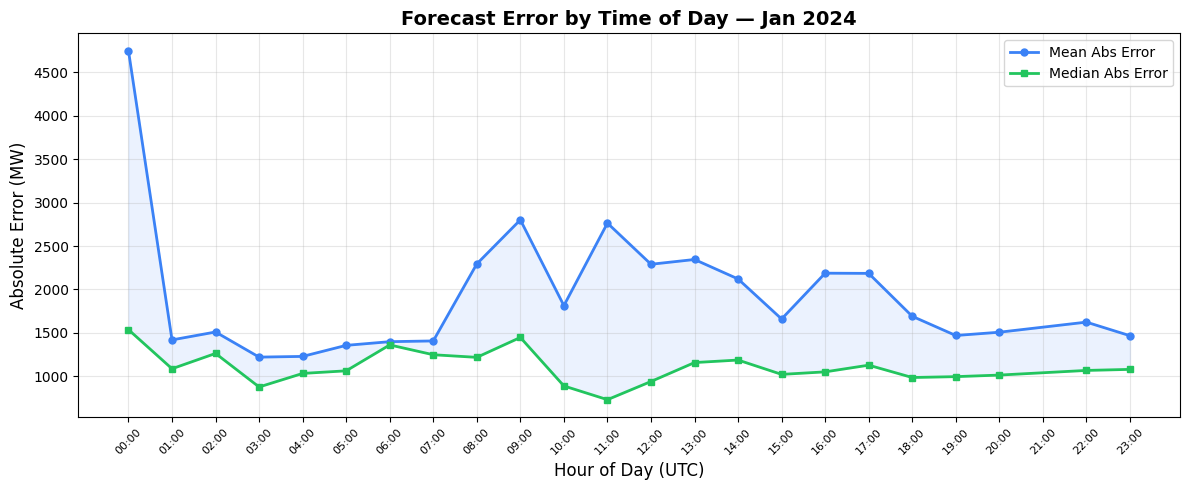

Chart saved.

Hourly breakdown:
 hour        mean  median  count
    0 4746.950000  1537.5     60
    1 1419.854839  1088.0     62
    2 1510.709677  1264.0     62
    3 1221.741935   878.0     31
    4 1229.806452  1034.0     31
    5 1357.000000  1064.0     31
    6 1399.387097  1362.0     31
    7 1407.935484  1249.0     31
    8 2294.193548  1219.0     31
    9 2801.258065  1448.0     31
   10 1814.322581   890.0     31
   11 2763.806452   732.0     31
   12 2290.161290   941.0     31
   13 2345.161290  1159.0     31
   14 2121.193548  1188.0     31
   15 1660.419355  1023.0     31
   16 2187.580645  1052.0     31
   17 2185.354839  1129.0     31
   18 1691.516129   987.0     31
   19 1470.500000   997.0     30
   20 1508.200000  1015.0     30
   22 1624.400000  1068.5     30
   23 1468.206897  1080.5     58


In [27]:
merged["hour"] = merged["startTime"].dt.hour
hourly_stats = merged.groupby("hour")["abs_error"].agg(
    mean="mean",
    median="median",
    count="count"
).reset_index()

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(hourly_stats["hour"], hourly_stats["mean"],
        color="#3b82f6", marker="o", linewidth=2,
        markersize=5, label="Mean Abs Error")
ax.plot(hourly_stats["hour"], hourly_stats["median"],
        color="#22c55e", marker="s", linewidth=2,
        markersize=5, label="Median Abs Error")

ax.fill_between(hourly_stats["hour"],
                hourly_stats["mean"],
                hourly_stats["median"],
                alpha=0.1, color="#3b82f6")

ax.set_xlabel("Hour of Day (UTC)", fontsize=12)
ax.set_ylabel("Absolute Error (MW)", fontsize=12)
ax.set_title("Forecast Error by Time of Day — Jan 2024", fontsize=14, fontweight="bold")
ax.set_xticks(range(0, 24))
ax.set_xticklabels([f"{h:02d}:00" for h in range(24)], rotation=45, fontsize=8)
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("error_by_hour.png", dpi=150)
plt.show()
print("Chart saved.")
print()
print("Hourly breakdown:")
print(hourly_stats.to_string(index=False))

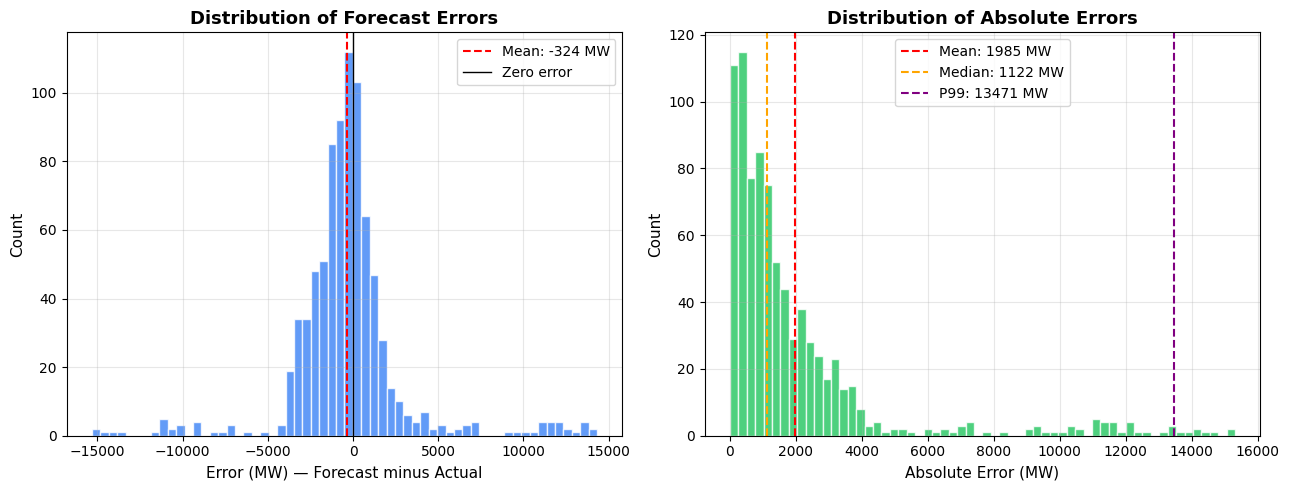

Chart saved.


In [28]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: histogram of raw errors (signed)
axes[0].hist(merged["error"], bins=60, color="#3b82f6",
             alpha=0.8, edgecolor="white")
axes[0].axvline(merged["error"].mean(), color="red",
                linestyle="--", linewidth=1.5, label=f"Mean: {merged['error'].mean():.0f} MW")
axes[0].axvline(0, color="black", linestyle="-", linewidth=1, label="Zero error")
axes[0].set_xlabel("Error (MW) — Forecast minus Actual", fontsize=11)
axes[0].set_ylabel("Count", fontsize=11)
axes[0].set_title("Distribution of Forecast Errors", fontsize=13, fontweight="bold")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Right: histogram of absolute errors
axes[1].hist(merged["abs_error"], bins=60, color="#22c55e",
             alpha=0.8, edgecolor="white")
axes[1].axvline(merged["abs_error"].mean(), color="red",
                linestyle="--", linewidth=1.5, label=f"Mean: {merged['abs_error'].mean():.0f} MW")
axes[1].axvline(merged["abs_error"].median(), color="orange",
                linestyle="--", linewidth=1.5, label=f"Median: {merged['abs_error'].median():.0f} MW")
axes[1].axvline(merged["abs_error"].quantile(0.99), color="purple",
                linestyle="--", linewidth=1.5, label=f"P99: {merged['abs_error'].quantile(0.99):.0f} MW")
axes[1].set_xlabel("Absolute Error (MW)", fontsize=11)
axes[1].set_ylabel("Count", fontsize=11)
axes[1].set_title("Distribution of Absolute Errors", fontsize=13, fontweight="bold")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("error_distribution.png", dpi=150)
plt.show()
print("Chart saved.")

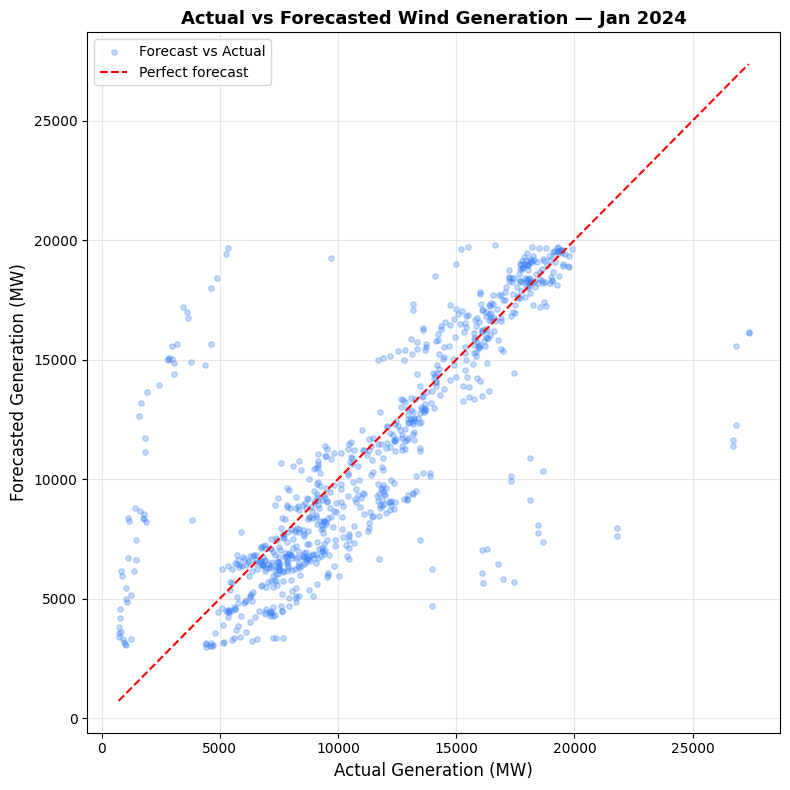

Chart saved.


In [29]:
fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(merged["generation_actual"], merged["generation_forecast"],
           alpha=0.3, color="#3b82f6", s=15, label="Forecast vs Actual")

min_val = min(merged["generation_actual"].min(), merged["generation_forecast"].min())
max_val = max(merged["generation_actual"].max(), merged["generation_forecast"].max())
ax.plot([min_val, max_val], [min_val, max_val],
        color="red", linestyle="--", linewidth=1.5, label="Perfect forecast")

ax.set_xlabel("Actual Generation (MW)", fontsize=12)
ax.set_ylabel("Forecasted Generation (MW)", fontsize=12)
ax.set_title("Actual vs Forecasted Wind Generation — Jan 2024",
             fontsize=13, fontweight="bold")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("actual_vs_forecast_scatter.png", dpi=150)
plt.show()
print("Chart saved.")

## Forecast Error Analysis — Summary

**Dataset:** UK national wind power generation, January 2024
**Source:** Elexon BMRS API (WINDFOR + FUELHH)
**Paired observations:** 828 (forecast horizon 0–48h)

### Key Findings

| Metric | Value |
|---|---|
| Mean Absolute Error | 1,985 MW |
| Median Absolute Error | 1,122 MW |
| P99 Absolute Error | 13,471 MW |
| RMSE | 3,356 MW |
| Mean Bias | -324 MW (under-forecast) |

### Error vs Horizon
Error increases with forecast horizon as expected:
- 0–6h: MAE 1,749 MW
- 6–12h: MAE 1,846 MW  
- 12–24h: MAE 2,026 MW
- 36–48h: MAE 2,359 MW

Median error stays relatively flat (~1,000–1,200 MW) across horizons,
suggesting outlier events drive most of the mean error increase.

### Error by Time of Day
- Highest mean error at 00:00 (4,747 MW) — driven by outliers
- Lowest errors in early morning 03:00–07:00 (~1,200–1,400 MW)
- Secondary peaks at 09:00 and 11:00 (~2,800 MW) during morning wind ramp-up

### Error Distribution
Errors are right-skewed with a heavy tail. The gap between
mean (1,985 MW) and median (1,122 MW) indicates a small number
of large forecast misses significantly inflate the average error.
The model has a slight systematic under-forecasting bias of 324 MW.